# Project Title : Internship Project - RiceLeaf disease detection
### Project Description : 
- This project focuses on classifying rice leaf images into three major disease categories, bacterial leaf blight, brown spot, and leaf smut, using image data collected from infected rice plants. The dataset includes 119 jpg images spread across the three classes. The main goal is to build a deep learning model, using convolutional neural networks along with techniques like data augmentation and transfer learning, which can classify the disease type with good accuracy.

### Project Team Id, Project Id and Deadlines :
- **Project Team ID** : PTID-CDS-JUL-26-11133
- **Project ID** : PRCP• 1001- RiceLeaf disease detection
- **Institute** : DataMites

# Import and Configuration :

In [1]:
# To intrect with data
import pandas as pd 
# To visualize the data
import matplotlib.pyplot as plt
import seaborn as sns 

# To ignore the warnings 
import warnings 
warnings.filterwarnings("ignore")

In [2]:
# Fix random values so results stay the same every time this notebook runs
import tensorflow as tf
import numpy as np
import random

SEED = 42
random.seed(SEED)       # Fixes Python's own random number generator
np.random.seed(SEED)    # Fixes NumPy's random number generator
tf.random.set_seed(SEED)  # Fixes TensorFlow's random number generator (model weights, shuffling)

In [3]:
# To check what files and folders are sitting next to this notebook
import pathlib
list(pathlib.Path(".").iterdir())

[WindowsPath('.ipynb_checkpoints'),
 WindowsPath('Bacterial leaf blight'),
 WindowsPath('Bacterial leaf blight.zip'),
 WindowsPath('best_aug_model.keras'),
 WindowsPath('best_model.keras'),
 WindowsPath('Brown spot'),
 WindowsPath('Brown spot.zip'),
 WindowsPath('final_transfer_model.keras'),
 WindowsPath('Leaf smut'),
 WindowsPath('Leaf smut.zip'),
 WindowsPath('RiceLeaf disease.ipynb')]

In [4]:
# To install TensorFlow - this library used to build the CNN
!pip install tensorflow

# Load Data :

In [5]:
import tensorflow as tf

In [6]:
# Fixed size every image will be resized to
IMG_SIZE = (160, 160)
BATCH_SIZE = 8

# To load all images from the 3 class folders, resize them, and auto-label by folder name
dataset = tf.keras.utils.image_dataset_from_directory(
    ".",
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE
)

print("Classes found:", dataset.class_names)

Found 119 files belonging to 3 classes.
Classes found: ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']


### Insight / Why?
- **What:** Loaded all 119 images directly from the 3 class folders, automatically labeled by folder name.
- **Why:** Confirms the data pipeline works correctly, all images and all 3 classes were picked up with nothing missing.

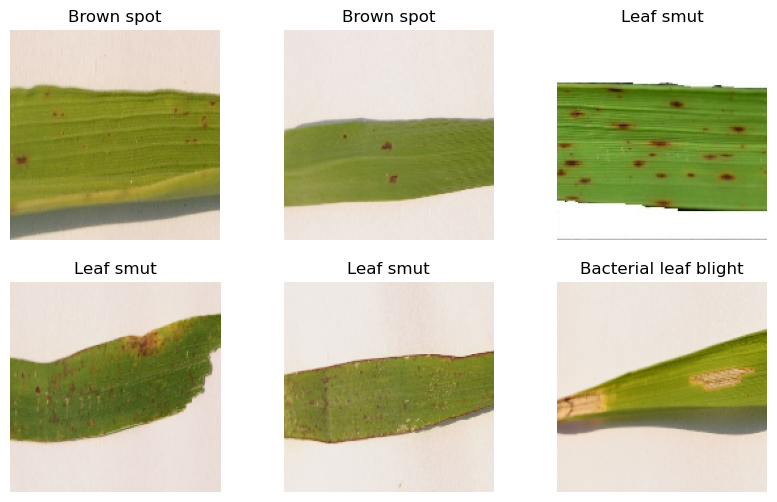

In [7]:
# To grab one batch (8 images) to inspect
images, labels = next(iter(dataset))

plt.figure(figsize = (10, 6))

# Show 6 sample images with their disease label
plt.subplot(2, 3, 1)
plt.imshow(images[0].numpy().astype("uint8"))
plt.title(dataset.class_names[labels[0]])
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(images[1].numpy().astype("uint8"))
plt.title(dataset.class_names[labels[1]])
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(images[2].numpy().astype("uint8"))
plt.title(dataset.class_names[labels[2]])
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(images[3].numpy().astype("uint8"))
plt.title(dataset.class_names[labels[3]])
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(images[4].numpy().astype("uint8"))
plt.title(dataset.class_names[labels[4]])
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(images[5].numpy().astype("uint8"))
plt.title(dataset.class_names[labels[5]])
plt.axis("off")

plt.show()

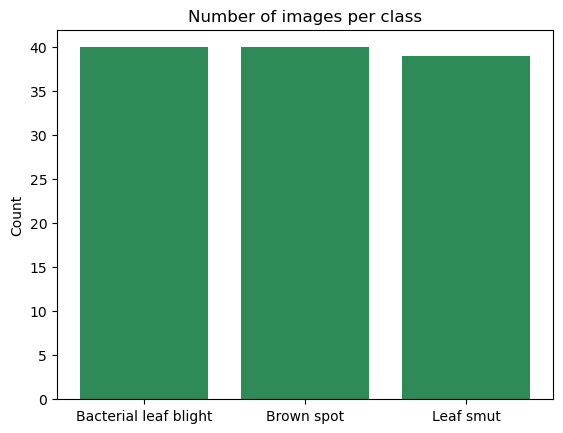

In [8]:
import pathlib

# To count how many images are in each class folder
blb_count = len([f for f in pathlib.Path("Bacterial leaf blight").rglob("*") if f.is_file()])
bs_count = len([f for f in pathlib.Path("Brown spot").rglob("*") if f.is_file()])
ls_count = len([f for f in pathlib.Path("Leaf smut").rglob("*") if f.is_file()])

plt.bar(["Bacterial leaf blight", "Brown spot", "Leaf smut"], [blb_count, bs_count, ls_count], color="seagreen")
plt.title("Number of images per class")
plt.ylabel("Count")
plt.show()

### Insight / Why?
- **What:** Original image sizes vary heavily between classes. Bacterial leaf blight and Leaf smut samples are 897x3081, wide panoramic shots, while the Brown spot sample is only 250x766.
- **Why:** Confirms the photos weren't captured in a consistent size or format, which is why resizing every image to 160x160 during loading was necessary before training.

In [9]:
files1 = [f for f in pathlib.Path("Bacterial leaf blight").rglob("*") if f.is_file()]
files2 = [f for f in pathlib.Path("Brown spot").rglob("*") if f.is_file()]
files3 = [f for f in pathlib.Path("Leaf smut").rglob("*") if f.is_file()]

img1 = plt.imread(files1[0])
img2 = plt.imread(files2[0])
img3 = plt.imread(files3[0])

print("Bacterial leaf blight shape:", img1.shape)
print("Brown spot shape:", img2.shape)
print("Leaf smut shape:", img3.shape)

Bacterial leaf blight shape: (897, 3081, 3)
Brown spot shape: (250, 766, 3)
Leaf smut shape: (897, 3081, 3)


# Split The Data Into Train/Test/Validation :

In [10]:
# 80% for training
train_ds = tf.keras.utils.image_dataset_from_directory(
    ".",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# remaining 20% for testing
test_ds = tf.keras.utils.image_dataset_from_directory(
    ".",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 119 files belonging to 3 classes.
Using 96 files for training.
Found 119 files belonging to 3 classes.
Using 23 files for validation.


In [11]:
print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_ds).numpy())

Train batches: 12
Test batches: 3


### Insight / Why?
- **What:** 12 batches of 8 for training (~95 images), 3 batches of 8 for testing (~24 images).
- **Why:** Confirms the 80/20 split worked correctly and matches the expected image counts.

# Build the CNN Model :

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Rescaling, Conv2D, MaxPooling2D, Flatten, Dropout, Dense

# Create an empty model, we add layers one by one
model = Sequential()

# Scale pixel values from 0-255 down to 0-1
model.add(Rescaling(1./255, input_shape=(160, 160, 3)))

# First conv block: learns basic patterns, then shrinks the image
model.add(Conv2D(16, 3, activation='relu'))
model.add(MaxPooling2D())

# Second conv block: learns more complex patterns
model.add(Conv2D(32, 3, activation='relu'))
model.add(MaxPooling2D())

# Third conv block: learns even more detailed patterns
model.add(Conv2D(64, 3, activation='relu'))
model.add(MaxPooling2D())

# Flatten the image data into a single long list of numbers
model.add(Flatten())

# Dense layer to combine everything learned so far
model.add(Dense(64, activation='relu'))

# Randomly turn off 40% of neurons during training, reduces overfitting
model.add(Dropout(0.4))

# Output layer: 3 classes, gives a probability for each disease
model.add(Dense(3, activation='softmax'))

# Print the full model structure
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)                │ (None, 160, 160, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 158, 158, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 79, 79, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 77, 77, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 38, 38, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 36, 36, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 18, 18, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 20736)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │       1,327,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,350,947 (5.15 MB)

 Trainable params: 1,350,947 (5.15 MB)

 Non-trainable params: 0 (0.00 B)

### Insight / Why?
- **What:** The model has 1,350,947 trainable parameters, built from 3 Conv2D+MaxPooling2D blocks followed by a dense layer.
- **Why:** A reasonable size for a small dataset, big enough to learn patterns, not so massive that it's guaranteed to overfit instantly. Dropout(0.4) helps offset the overfitting risk that comes with only ~95 training images.

# Compile the model :

In [13]:
# adam: adjusts learning speed automatically as training goes
# loss: since labels are plain numbers (0,1,2), not one-hot, we use sparse_categorical_crossentropy
# metrics: track accuracy while training
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train the Model

In [14]:
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping

In [15]:
# Save the best version of the model while training
cp = ModelCheckpoint(filepath='best_model.keras', save_best_only=True, verbose=1)
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=13,
    callbacks=[cp]
)

Epoch 1/13
10/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3375 - loss: 1.1537
Epoch 1: val_loss improved from None to 1.09163, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.3542 - loss: 1.1422 - val_accuracy: 0.3478 - val_loss: 1.0916
Epoch 2/13
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5000 - loss: 1.0348
Epoch 2: val_loss did not improve from 1.09163
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5000 - loss: 1.0348 - val_accuracy: 0.3478 - val_loss: 1.1190
Epoch 3/13
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5208 - loss: 0.9447
Epoch 3: val_loss improved from 1.09163 to 1.06074, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5208 - loss: 0.9447 - val_accuracy: 0.3913 - val_loss: 1.0607
Epoch 4/13
10/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5250 - loss: 0

In [16]:
model.load_weights('best_model.keras')

test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6522 - loss: 0.7887
Test Loss: 0.7887134552001953
Test Accuracy: 0.6521739363670349


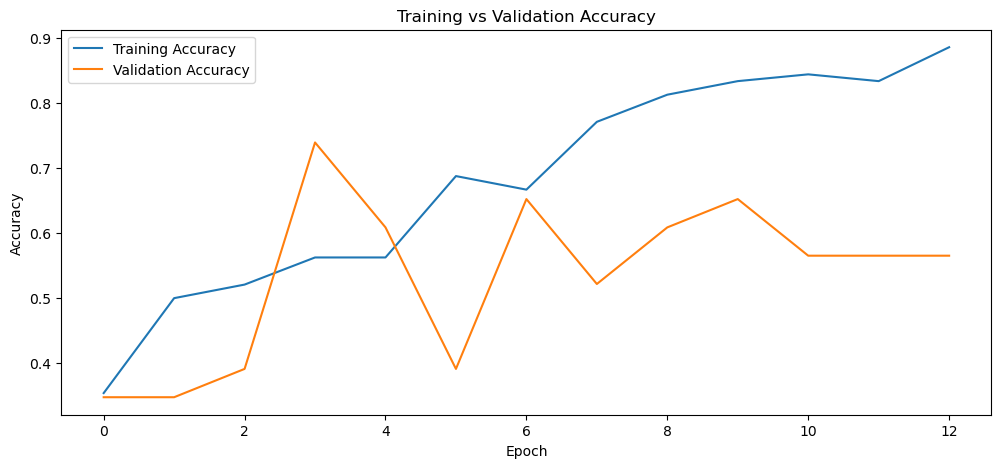

In [17]:
plt.figure(figsize=(12,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend(); plt.show()

### Insight / Why?
- **What:** Test accuracy came out to 65.2%. The curve shows training accuracy climbing steadily to ~89%, while validation accuracy stays unstable throughout, bouncing between roughly 35% and 74%, ending around 57%.
- **Why:** Classic overfitting, the model is learning to memorize training images rather than general disease patterns. Expected with only ~95 training images and no augmentation.

# CNN with Data Augmentation :

In [18]:
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom 

aug_model = Sequential()

# Randomly flip, rotate and zoom image during training only 
aug_model.add(RandomFlip("horizontal", input_shape = (160, 160, 3)))
aug_model.add(RandomRotation(0.05))
aug_model.add(RandomZoom(0.15))

aug_model.add(Rescaling(1./255))
aug_model.add(Conv2D(16, 3, activation = "relu"))
aug_model.add(MaxPooling2D())
aug_model.add(Conv2D(32, 3, activation = "relu"))
aug_model.add(MaxPooling2D())
aug_model.add(Conv2D(64, 3, activation = "relu"))
aug_model.add(MaxPooling2D())
aug_model.add(Flatten())
aug_model.add(Dense(64, activation = "relu"))
aug_model.add(Dropout(0.4))
aug_model.add(Dense(3, activation = "softmax"))

aug_model.compile(optimizer = "adam", loss = "sparse_categorical_crossentropy", metrics = ["accuracy"])
aug_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)             │ (None, 160, 160, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_rotation (RandomRotation)     │ (None, 160, 160, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_zoom (RandomZoom)             │ (None, 160, 160, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling_1 (Rescaling)              │ (None, 160, 160, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 158, 158, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 79, 79, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 77, 77, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 38, 38, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 36, 36, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 18, 18, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 20736)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │       1,327,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,350,947 (5.15 MB)

 Trainable params: 1,350,947 (5.15 MB)

 Non-trainable params: 0 (0.00 B)

### Insight / Why?
- **What:** The augmented model has the exact same total parameters as the baseline, 1,350,947. The three new layers (RandomFlip, RandomRotation, RandomZoom) add 0 parameters each.
- **Why:** These layers don't learn anything, they just randomly change the image before it enters the network during training. Same architecture as before means any difference in results will come from the augmentation, not from a bigger or different model.

In [19]:
cp_aug = ModelCheckpoint(filepath='best_aug_model.keras', save_best_only=True, verbose=1)

history_aug = aug_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=17,
    callbacks=[cp_aug]
)

Epoch 1/17
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.4205 - loss: 1.3518
Epoch 1: val_loss improved from None to 1.09976, saving model to best_aug_model.keras

Epoch 1: finished saving model to best_aug_model.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.4062 - loss: 1.3309 - val_accuracy: 0.2609 - val_loss: 1.0998
Epoch 2/17
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4167 - loss: 1.0940
Epoch 2: val_loss did not improve from 1.09976
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4167 - loss: 1.0940 - val_accuracy: 0.2174 - val_loss: 1.1436
Epoch 3/17
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3646 - loss: 1.0795
Epoch 3: val_loss did not improve from 1.09976
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.3646 - loss: 1.0795 - val_accuracy: 0.2174 - val_loss: 1.1926
Epoch 4/17
10/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4375 - loss: 1.0486
Epoch 4: val_loss did not improve from 1.09976
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s

In [20]:
aug_model.load_weights('best_aug_model.keras')

test_loss_aug, test_accuracy_aug = aug_model.evaluate(test_ds, verbose=0)
print("Augmented Test Loss:", test_loss_aug)
print("Augmented Test Accuracy:", test_accuracy_aug)

Augmented Test Loss: 0.6141281723976135
Augmented Test Accuracy: 0.782608687877655


In [21]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D

In [22]:
# Load a model already trained over a million images 
base_model = MobileNetV2(input_shape = (160, 160, 3), include_top = False, weights = "imagenet")

# Freeze it, so training doesn't overwrite what it already learned 
base_model.trainable = False 

transfer_model = Sequential()

# MobileNetV2 expects pixel values between -1 and 1, not 0 - 1 like before  
transfer_model.add(Rescaling(1./127.5, offset = -1, input_shape = (160, 160, 3)))
transfer_model.add(base_model)
transfer_model.add(GlobalAveragePooling2D())
transfer_model.add(Dropout(0.3))
transfer_model.add(Dense(3, activation = "softmax"))

transfer_model.compile(optimizer = "adam", loss = "sparse_categorical_crossentropy", metrics = ["accuracy"])
transfer_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)              │ (None, 160, 160, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_160 (Functional)    │ (None, 5, 5, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 3)                   │           3,843 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# Train the Transfer Learning Model

In [23]:
# Train only the new top layers, base_model stays frozen
history_transfer = transfer_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 184ms/step - accuracy: 0.3958 - loss: 1.3560 - val_accuracy: 0.4783 - val_loss: 0.9703
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.5833 - loss: 1.0425 - val_accuracy: 0.6522 - val_loss: 0.8419
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.7917 - loss: 0.5256 - val_accuracy: 0.6957 - val_loss: 0.6029
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.8125 - loss: 0.4720 - val_accuracy: 0.7826 - val_loss: 0.4990
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.8750 - loss: 0.3363 - val_accuracy: 0.8696 - val_loss: 0.4878
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.9062 - loss: 0.2689 - val_accuracy: 0.8696 - val_loss: 0.4216
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.9375 - loss: 0.2390 - val_accuracy: 0.8696 - val_loss: 0.3859
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.9688 - loss: 0.1713 - val_accuracy: 0.8696 - 

### Insight / Why?
- **What:** Training accuracy climbed steadily from 79% to 97% over 10 epochs, while validation accuracy reached 87% by epoch 5 and stayed exactly there for the remaining epochs.
- **Why:** Only the small classifier head is training here, since `base_model` is frozen, there are far fewer parameters to adjust than a full CNN. That's why validation locks onto a stable value quickly instead of bouncing around like the baseline model did.

In [24]:
test_loss_transfer, test_accuracy_transfer = transfer_model.evaluate(test_ds, verbose=0)
print("Transfer Learning Test Loss:", test_loss_transfer)
print("Transfer Learning Test Accuracy:", test_accuracy_transfer)

Transfer Learning Test Loss: 0.33780521154403687
Transfer Learning Test Accuracy: 0.8695651888847351


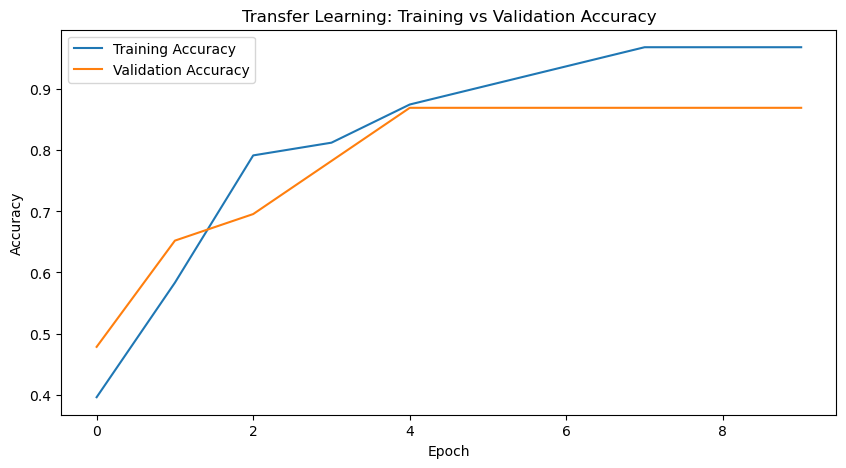

In [25]:
plt.figure(figsize=(10,5))
plt.plot(history_transfer.history['accuracy'], label='Training Accuracy')
plt.plot(history_transfer.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.title('Transfer Learning: Training vs Validation Accuracy')
plt.legend(); plt.show()

### Insight / Why?
- **What:** Test accuracy reached 87.0%, the best of all four models. Training accuracy climbed smoothly to ~97%, while validation accuracy also climbed steadily to 87% and then stayed flat, no wild swings like the baseline had.
- **Why:** Even though training accuracy is high, validation didn't just spike and collapse, it rose gradually and stabilized. Shows MobileNetV2's pretrained features generalize well even with very few training images, a real contrast to baseline's unstable curve.

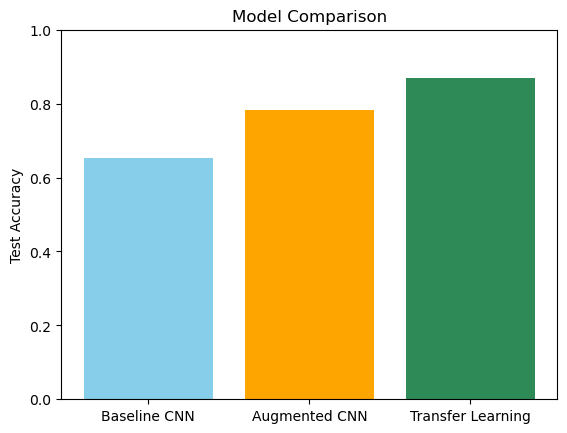

Baseline CNN Accuracy: 0.6521739363670349
Augmented CNN Accuracy: 0.782608687877655
Transfer Learning Accuracy: 0.8695651888847351


In [26]:
# Compare all three models' test accuracy
model_names = ["Baseline CNN", "Augmented CNN", "Transfer Learning"]
accuracies = [test_accuracy, test_accuracy_aug, test_accuracy_transfer]

plt.bar(model_names, accuracies, color=["skyblue", "orange", "seagreen"])
plt.ylabel("Test Accuracy")
plt.title("Model Comparison")
plt.ylim(0, 1)
plt.show()

print("Baseline CNN Accuracy:", test_accuracy)
print("Augmented CNN Accuracy:", test_accuracy_aug)
print("Transfer Learning Accuracy:", test_accuracy_transfer)

# Fine-Tuning the Transfer Learning Model :

In [27]:
# Unfreeze the base model, then re-lock all but its last 20 layers
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

from tensorflow.keras.optimizers import Adam

# Very low learning rate, so we adjust gently instead of wrecking what MobileNetV2 already knows
transfer_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_finetune = transfer_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 240ms/step - accuracy: 0.7917 - loss: 0.5204 - val_accuracy: 0.8696 - val_loss: 0.3327
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - accuracy: 0.8750 - loss: 0.4242 - val_accuracy: 0.8696 - val_loss: 0.3249
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 0.7396 - loss: 0.4611 - val_accuracy: 0.8696 - val_loss: 0.3202
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.8333 - loss: 0.3874 - val_accuracy: 0.8261 - val_loss: 0.3179
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - accuracy: 0.8750 - loss: 0.3272 - val_accuracy: 0.8261 - val_loss: 0.3136
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - accuracy: 0.9271 - loss: 0.2744 - val_accuracy: 0.8261 - val_loss: 0.3098
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - accuracy: 0.9167 - loss: 0.2518 - val_accuracy: 0.8261 - val_loss: 0.3080
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - accuracy: 0.8958 - loss: 0.3092 - val_accuracy: 0.8261 

In [28]:
test_loss_finetune, test_accuracy_finetune = transfer_model.evaluate(test_ds, verbose=0)
print("Fine-tuned Test Loss:", test_loss_finetune)
print("Fine-tuned Test Accuracy:", test_accuracy_finetune)

Fine-tuned Test Loss: 0.3060690462589264
Fine-tuned Test Accuracy: 0.8260869383811951


### Insight / Why?
- **What:** Validation accuracy jumped to 86.96% in epoch 1, then settled down to 82.61% by epoch 4 and stayed exactly there for the rest of training. Training accuracy, meanwhile, bounced around noisily between 74% and 93%, not a smooth climb like the frozen phase had.
- **Why:** Once unfrozen, the extra trainable layers make training less stable, small weight updates now affect more of the network at once. Validation loss kept slowly improving (0.33 → 0.31) even after accuracy flattened, meaning the model kept getting more confident without actually changing which images it got right or wrong.

In [29]:
train_loss_finetune, train_accuracy_finetune = transfer_model.evaluate(train_ds, verbose=0)
print("Fine-tuned Train Loss:", train_loss_finetune)
print("Fine-tuned Train Accuracy:", train_accuracy_finetune)

Fine-tuned Train Loss: 0.05021311342716217
Fine-tuned Train Accuracy: 1.0


In [30]:
transfer_model.save('final_transfer_model.keras')

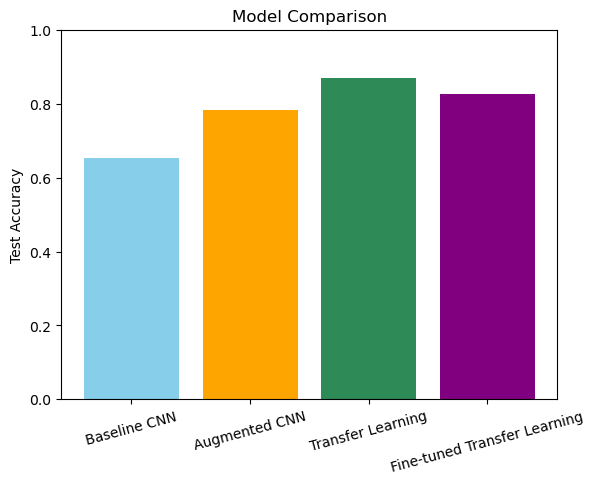

In [31]:
model_names = ["Baseline CNN", "Augmented CNN", "Transfer Learning", "Fine-tuned Transfer Learning"]
accuracies = [test_accuracy, test_accuracy_aug, test_accuracy_transfer, test_accuracy_finetune]

plt.bar(model_names, accuracies, color=["skyblue", "orange", "seagreen", "purple"])
plt.ylabel("Test Accuracy")
plt.title("Model Comparison")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.show()

In [32]:
print("Baseline CNN Accuracy:", test_accuracy)
print("Augmented CNN Accuracy:", test_accuracy_aug)
print("Transfer Learning Accuracy:", test_accuracy_transfer)
print("Fine-tuned Transfer Learning Accuracy:", test_accuracy_finetune)

Baseline CNN Accuracy: 0.6521739363670349
Augmented CNN Accuracy: 0.782608687877655
Transfer Learning Accuracy: 0.8695651888847351
Fine-tuned Transfer Learning Accuracy: 0.8260869383811951


### Insight / Why?
- **What:** The frozen transfer learning model scored 87.0% test accuracy. After fine-tuning (unfreezing the last 20 layers), accuracy dropped to 82.6%.
- **Why:** Unfreezing more layers gave the model extra flexibility to adjust, but with only ~95 training images, that flexibility led to slight overfitting instead of improvement. Confirms the frozen version generalizes better for a dataset this small.

 # Model Comparison Report :

Four models were trained and compared on the same test set of 23 images :

| Model | Test Accuracy |
|---|---|
| Baseline CNN | 65.2% |
| CNN with Data Augmentation | 78.3% |
| Transfer Learning (MobileNetV2, frozen) | 87.0% |
| Fine-tuned Transfer Learning | 82.6% |

- The baseline CNN struggled the most, reaching only 65.2% test accuracy. Training accuracy climbed much higher than validation accuracy, a clear overfitting pattern expected with only about 95 training images, not enough for a CNN to learn strong features from scratch.

- Adding data augmentation (random flip, rotation, zoom) improved accuracy noticeably to 78.3%, since the model saw more varied versions of the same images during training instead of memorizing exact ones.

- Transfer learning with a frozen MobileNetV2 base performed best at 87.0%. Since MobileNetV2 was already trained on over a million images, it already understands general visual features, so only a small classifier needed to be trained on top of it.

- Fine-tuning (unfreezing the last 20 layers with a very low learning rate) resulted in a lower accuracy of 82.6%. With a dataset this small, unlocking more layers gave the model more room to overfit rather than improve, so the frozen version generalized better.

**Recommended model for production: Transfer Learning with a frozen MobileNetV2 base**, based on the highest test accuracy among all four models tested.

# Report on Challenges Faced :

**Small dataset.** Only 119 images across three classes, about 40 per class. This limited how well a CNN could learn from scratch, and is the main reason transfer learning outperformed the other approaches.

**Inconsistent photo style.** Images varied heavily in size and framing, some were wide full-leaf shots, others close-up crops. All images were resized to a fixed 160x160 size before training, which distorted some photos more than others.

**Small test set.** With only 23 test images, each misclassified image shifts accuracy by roughly 4%. Results should be read as a general trend, not an exact fixed number.

**Fine-tuning did not help.** Unfreezing part of MobileNetV2 and retraining with a low learning rate produced a lower accuracy (82.6%) than the frozen version (87.0%), likely because the training set was too small to safely adjust that many additional parameters.

**Techniques used and why:** data augmentation was used to increase variety in the training data and reduce overfitting. Transfer learning was used because the dataset was too small to train a deep CNN from scratch effectively, so a pretrained MobileNetV2 model was used as a fixed feature extractor, which turned out to be the strongest approach overall.